In [1]:
# --- 這段是 02_eda.ipynb 的第一格 ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings
import os

# 1. 忽略警告並設定中文
warnings.filterwarnings('ignore')

def set_ch_font():
    system = platform.system()
    if system == "Windows": 
        plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
    elif system == "Darwin": 
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

set_ch_font()
sns.set_theme(style="whitegrid", font=plt.rcParams['font.sans-serif'])

# 2. 讀取 01 產出的「清理後」表格
data_path = '../data/processed/cleaned_cycle3.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    # 建立視覺化用的標籤
    df['Group_Label'] = df['Smoking_Status'].map({0: '不吸菸組 (No)', 1: '吸菸組 (Yes)'})
    print(f"✅ 資料讀取成功！")
    print(f"有效樣本共 {len(df)} 筆，包含欄位：{list(df.columns)}")
else:
    print(f"❌ 找不到檔案：{data_path}")
    print("💡 請先確認是否已執行 01_data_check.ipynb 中的儲存步驟。")

✅ 資料讀取成功！
有效樣本共 12437 筆，包含欄位：['CurrentCigaretteUse', 'BMIPCT', 'Smoking_Status', 'Group_Label']


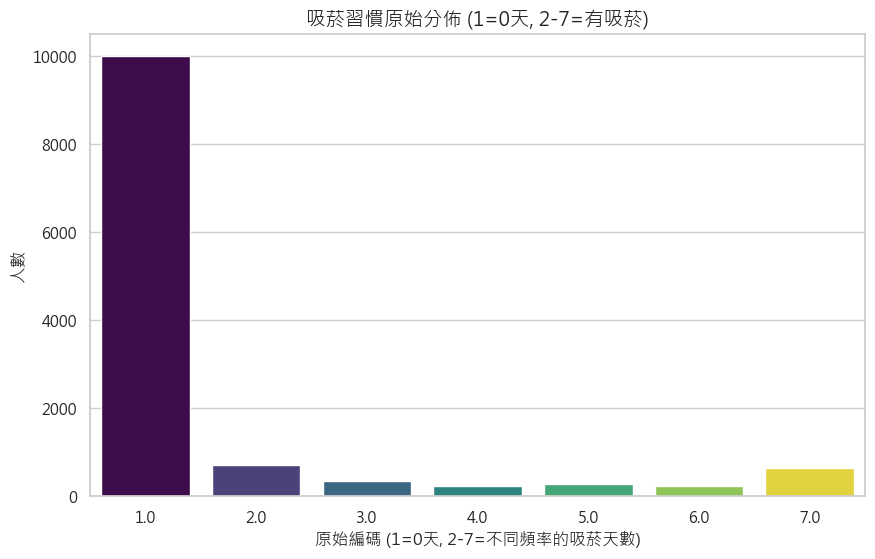

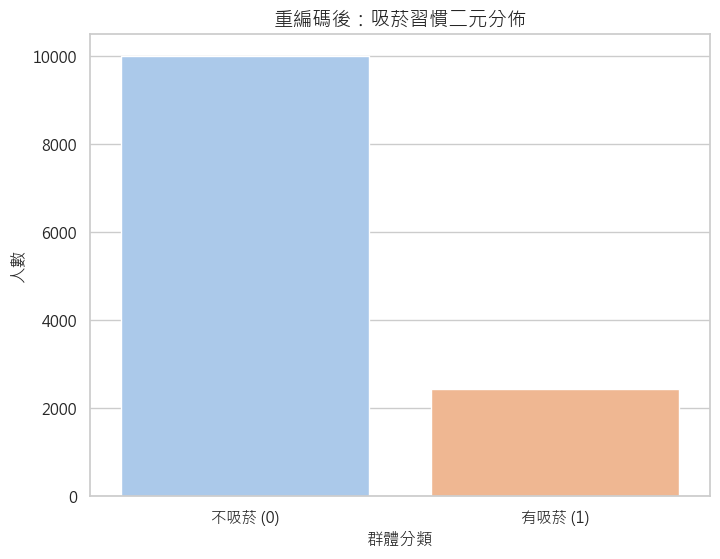

✅ 吸菸變數處理完成，有效樣本數：12437


In [2]:
# 1. 排除吸菸習慣缺失值並建立副本
df_smoke = df.dropna(subset=['CurrentCigaretteUse']).copy()

# 2. 原始分佈圖 (圖 A)
# 目的：觀察 1-7 分類下，各個使用天數頻率的人數
fig_smoke_raw = plt.figure(figsize=(10, 6))
sns.countplot(x='CurrentCigaretteUse', data=df_smoke, palette='viridis', hue='CurrentCigaretteUse', legend=False)
plt.title('吸菸習慣原始分佈 (1=0天, 2-7=有吸菸)', fontsize=14)
plt.xlabel('原始編碼 (1=0天, 2-7=不同頻率的吸菸天數)', fontsize=12)
plt.ylabel('人數', fontsize=12)
plt.show()

# 3. 執行二元重編碼 (Recoding)
# 定義：1 (0天) -> 0 (不吸菸) ; 2~7 (1天以上) -> 1 (有吸菸)
# 統一命名為 Smoking_Status 以符合後續分析
df_smoke['Smoking_Status'] = df_smoke['CurrentCigaretteUse'].apply(lambda x: 0 if x == 1 else 1)

# 4. 二元化分佈圖 (圖 B)
# 目的：確認簡化後的「對照組」與「實驗組」人數比例
fig_smoke_bin = plt.figure(figsize=(8, 6))
sns.countplot(x='Smoking_Status', data=df_smoke, palette='pastel', hue='Smoking_Status', legend=False)
plt.xticks([0, 1], ['不吸菸 (0)', '有吸菸 (1)'])
plt.title('重編碼後：吸菸習慣二元分佈', fontsize=14)
plt.xlabel('群體分類', fontsize=12)
plt.ylabel('人數', fontsize=12)
plt.show()

# 5. 儲存這兩張重要圖表
save_path = '../outputs/figures/'
if not os.path.exists(save_path): os.makedirs(save_path)

fig_smoke_raw.savefig(save_path + '02_smoking_raw_dist.png', dpi=300, bbox_inches='tight')
fig_smoke_bin.savefig(save_path + '02_smoking_binary_dist.png', dpi=300, bbox_inches='tight')

print(f"✅ 吸菸變數處理完成，有效樣本數：{len(df_smoke)}")

In [5]:
# --- 1. 吸菸變數：原始編碼頻率表 ---
print("【表 2-1：CurrentCigaretteUse 原始頻率表】")
# 統計原始 1-7 代碼的人數分佈，包含 NaN (缺失值)
# 1=0天, 2=1-2天, 3=3-5天, 4=6-9天, 5=10-19天, 6=20-29天, 7=30天
original_freq = df['CurrentCigaretteUse'].value_counts(dropna=False).sort_index()
print(original_freq)

# --- 2. 缺失與無效值計算 ---
missing_smoke = df['CurrentCigaretteUse'].isnull().sum()
# 假設有效範圍是 1-7，排除掉 NaN 後檢查是否有範圍外的數值
invalid_smoke = len(df[~df['CurrentCigaretteUse'].isin(range(1, 8)) & df['CurrentCigaretteUse'].notnull()])

print(f"\n缺失值數量: {missing_smoke}")
print(f"無效值數量: {invalid_smoke}")

# --- 3. 重編碼後的頻率與比例 ---
# 使用上一步處理好的 df_smoke (已排除缺失值)
# 0 = 不吸菸, 1 = 有吸菸行為
smoke_stats = df_smoke['Smoking_Status'].value_counts().sort_index()
smoke_proportions = df_smoke['Smoking_Status'].value_counts(normalize=True).sort_index()

summary_table_smoke = pd.DataFrame({
    '人數 (Counts)': smoke_stats,
    '比例 (Proportions)': smoke_proportions.map(lambda x: f"{x:.2%}") # 轉換為百分比格式
})

# 修改索引名稱讓表格更易讀
summary_table_smoke.index = ['不吸菸 (0)', '有吸菸 (1)']

print("\n【表 2-2：重編碼後之吸菸習慣統計 (0=不吸菸, 1=有吸菸)】")
print(summary_table_smoke)

【表 2-1：CurrentCigaretteUse 原始頻率表】
CurrentCigaretteUse
1.0    10003
2.0      720
3.0      353
4.0      235
5.0      270
6.0      221
7.0      635
Name: count, dtype: int64

缺失值數量: 0
無效值數量: 0

【表 2-2：重編碼後之吸菸習慣統計 (0=不吸菸, 1=有吸菸)】
         人數 (Counts) 比例 (Proportions)
不吸菸 (0)        10003           80.43%
有吸菸 (1)         2434           19.57%


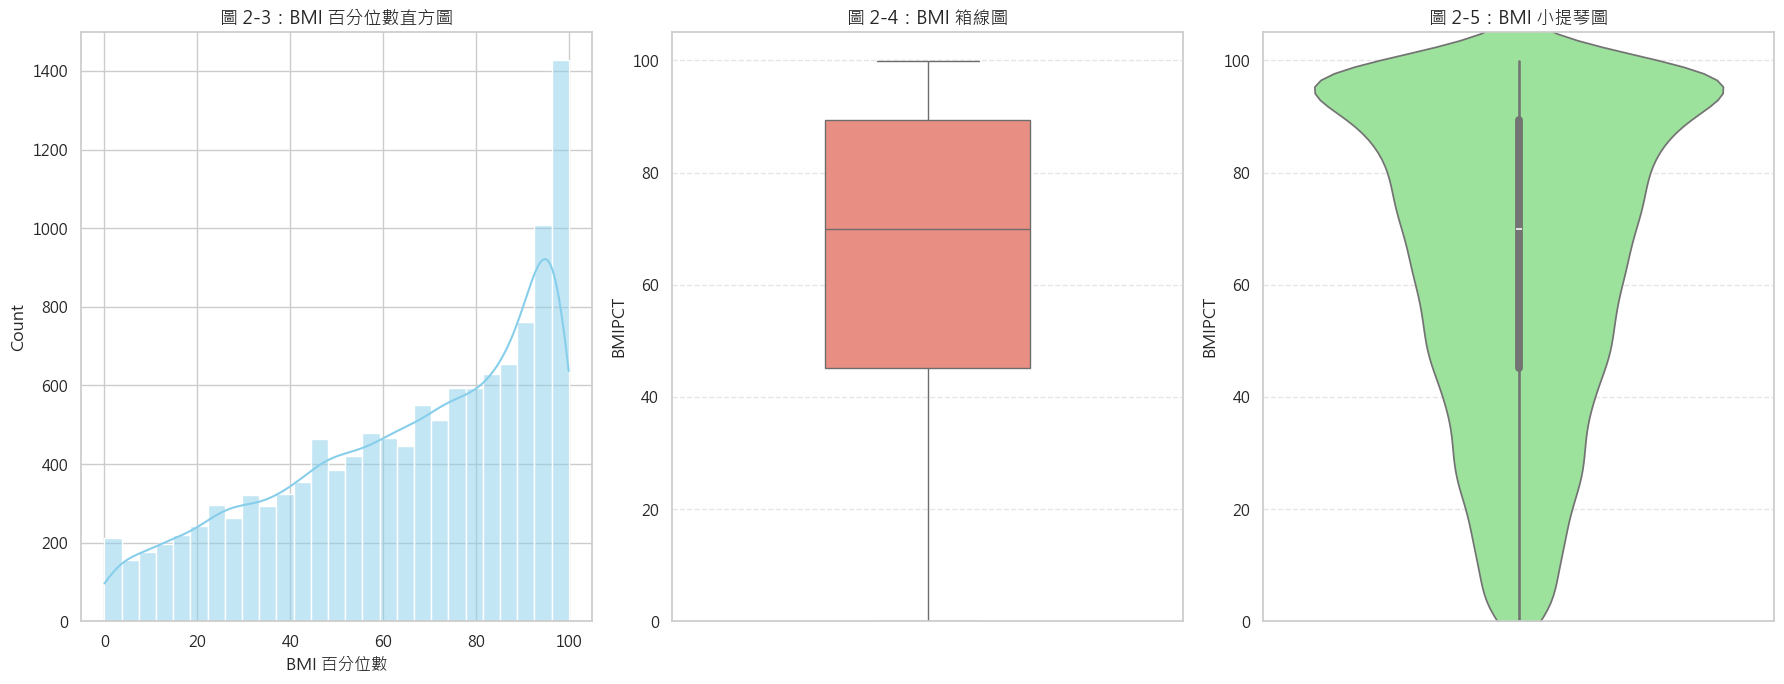

✅ BMI 分佈分析完成，有效樣本數：12437


In [18]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 排除 BMI 百分位數缺失值並建立副本
df_bmi = df.dropna(subset=['BMIPCT']).copy()

# --- 2. 建立一個「橫向排版」的大圖 (1列3欄) ---
# 這樣可以讓所有圖表一次展開在螢幕內，不會太長而捲動
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# (A) 直方圖 (Histogram)
sns.histplot(df_bmi['BMIPCT'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('圖 2-3：BMI 百分位數直方圖', fontsize=13)
axes[0].set_xlabel('BMI 百分位數')

# (B) 箱線圖 (Boxplot) - 拉長 Y 軸
sns.boxplot(y=df_bmi['BMIPCT'], color='salmon', width=0.4, ax=axes[1])
axes[1].set_ylim(0, 105)
axes[1].set_title('圖 2-4：BMI 箱線圖', fontsize=13)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# (C) 小提琴圖 (Violin Plot) - 拉長 Y 軸
sns.violinplot(y=df_bmi['BMIPCT'], color="lightgreen", ax=axes[2])
axes[2].set_ylim(0, 105)
axes[2].set_title('圖 2-5：BMI 小提琴圖', fontsize=13)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

# 優化間距
plt.tight_layout()
plt.show()

# --- 3. 儲存圖表 ---
save_path = '../outputs/figures/'
if not os.path.exists(save_path): 
    os.makedirs(save_path)

# 儲存這張「三合一」的完整分析圖
fig.savefig(save_path + '02_bmi_combined_dist.png', dpi=300, bbox_inches='tight')

print(f"✅ BMI 分佈分析完成，有效樣本數：{len(df_bmi)}")

In [19]:
# --- 1. BMI 百分位數描述性統計 ---
# 使用已排除缺失值的副本
bmi_series = df_bmi['BMIPCT']

# 計算各項指標
desc_stats = {
    '樣本數 (n)': len(bmi_series),
    '平均值 (Mean)': bmi_series.mean(),
    '中位數 (Median)': bmi_series.median(),
    '標準差 (SD)': bmi_series.std(),
    '最小值 (Min)': bmi_series.min(),
    '第一四分位數 (Q1)': bmi_series.quantile(0.25),
    '第三四分位數 (Q3)': bmi_series.quantile(0.75),
    '最大值 (Max)': bmi_series.max(),
    '缺失值數量 (原始全表)': df['BMIPCT'].isnull().sum()
}

print("【表 2-3：BMI 百分位數數據統計摘要】")
for k, v in desc_stats.items(): 
    print(f"{k}: {v:.2f}")

# --- 2. 離群值檢查 (Outlier Check) ---
# 使用 IQR 法：定義超過 Q3 + 1.5*IQR 或低於 Q1 - 1.5*IQR 為離群值
Q1 = bmi_series.quantile(0.25)
Q3 = bmi_series.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 篩選離群值
outliers = bmi_series[(bmi_series < lower_bound) | (bmi_series > upper_bound)]

print("-" * 30)
print(f"離群值判定界線 (IQR法): [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"偵測到離群值數量: {len(outliers)}")

if len(outliers) > 0:
    print(f"離群值佔比: {(len(outliers) / len(bmi_series)):.2%}")
else:
    print("在此變數中未偵測到統計學上的離群值。")

【表 2-3：BMI 百分位數數據統計摘要】
樣本數 (n): 12437.00
平均值 (Mean): 64.75
中位數 (Median): 70.01
標準差 (SD): 27.50
最小值 (Min): 0.00
第一四分位數 (Q1): 45.15
第三四分位數 (Q3): 89.29
最大值 (Max): 99.94
缺失值數量 (原始全表): 0.00
------------------------------
離群值判定界線 (IQR法): [-21.05, 155.49]
偵測到離群值數量: 0
在此變數中未偵測到統計學上的離群值。
